In [17]:
# ============================================================
# Cell 1: Imports & Setup
# ============================================================

# Python Standard Libraries
import os
import pickle
import time
import json
from dataclasses import dataclass, field, asdict
from typing import Tuple

# External Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# PyTorch Core libraries
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# timm: PyTorch Image Models | Used for transfer learning
import timm

# Scikit-Learn Libraries 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report, confusion_matrix

def set_seed(seed=42):
    """
    Set random seeds for reproducibility across numpy, PyTorch CPU and CUDA.

    Parameters:
        seed (int): The seed value to use for all random number generators.
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Ensure deterministic behaviour (Heavily impacts performance but allows for reproducible results)
    torch.backends.cudnn.deterministic = True
    
    # Provides a processing & speed boost, implemented as we utilize fixed input sizes :D
    # torch.backends.cudnn.benchmark = True

set_seed(42)
print(f"Imports complete, seed set: 42")

Imports complete, seed set: 42


In [19]:
# ============================================================
# Cell 1.1: Parameters & Hyperparameters Designation
# ============================================================

@dataclass
class DataConfig:
    """Data loading and preprocessing parameters."""
    img_size: int = 224             # Fixed Input Size
    batch_size: int = 32            # Batch Size of images
    num_workers: int = 0            # Set to 0 on windows, 4+ on Linux/Colab/Kaggle
    test_size: float = 0.30         # 70/15/15 splits
    val_split: float = 0.50         # split of temp → val/test (30=15/15)

@dataclass
class AugmentConfig:
    """Training augmentation parameters."""
    rotation: int = 20
    brightness: float = 0.2
    contrast: float = 0.2
    saturation: float = 0.2
    hue: float = 0.1
    translate: Tuple[float, float] = (0.1, 0.1)
    scale: Tuple[float, float] = (0.9, 1.1)
    flip_p: float = 0.5

@dataclass
class ModelConfig:
    """Model architecture parameters."""
    backbone: str = "efficientnet_b0"
    pretrained: bool = True
    meta_hidden: Tuple[int, int] = (64, 32)
    meta_dropout: float = 0.3
    classifier_hidden: int = 512
    classifier_dropout: float = 0.4
    freeze_backbone: bool = True

@dataclass
class TrainConfig:
    """Training loop parameters."""
    epochs: int = 25
    lr: float = 1e-3
    weight_decay: float = 1e-4
    unfreeze_epoch: int = 5
    patience: int = 7
    min_delta: float = 0.001
    backbone_lr_factor: float = 0.1

@dataclass
class Config:
    """Master configuration combining all parameter groups."""
    data: DataConfig = field(default_factory =   DataConfig)
    aug: AugmentConfig = field(default_factory = AugmentConfig)
    model: ModelConfig = field(default_factory = ModelConfig)
    train: TrainConfig = field(default_factory = TrainConfig)

cfg = Config()

In [108]:
# This cell is specifically intended if you're running it on google colab or kaggle :D
# Uncomment it and comment out the relevant code in Cell 2 including the DATA_ROOT by using (ctrl + /).

# !pip install --upgrade kagglehub
# import kagglehub
# path = "content/datasets"
# path = kagglehub.dataset_download("mahdavi1202/skin-cancer")
# path = kagglehub.dataset_download("spacesurfer/ph2-dataset")
# path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
# path = kagglehub.dataset_download("andrewmvd/isic-2019")

# PATHS = {
#     'ham10000': {
#         'base': '/kaggle/input/skin-cancer-mnist-ham10000',
#         'images_1': '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1',
#         'images_2': '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2',
#         'metadata': '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv'
#     },
#     'isic_2019': {
#         'base': '/kaggle/input/isic-2019',
#         'images': '/kaggle/input/isic-2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input',
#         'metadata': '/kaggle/input/isic-2019/ISIC_2019_Training_Metadata.csv',
#         'labels': '/kaggle/input/isic-2019/ISIC_2019_Training_GroundTruth.csv'
#     },
#     'ph2': {
#         'base': '/kaggle/input/ph2-dataset',
#         'metadata': '/kaggle/input/ph2-dataset/PH2Dataset/PH2_dataset.xlsx',
#         'images': '/kaggle/input/ph2-dataset/PH2Dataset/PH2 Dataset images'
#     },
#     'pad_ufes_20': {
#         'base': '/kaggle/input/skin-cancer',
#         'images_1': '/kaggle/input/skin-cancer/imgs_part_1/imgs_part_1',
#         'images_2': '/kaggle/input/skin-cancer/imgs_part_2/imgs_part_2',
#         'images_3': '/kaggle/input/skin-cancer/imgs_part_3/imgs_part_3',
#         'metadata': '/kaggle/input/skin-cancer/metadata.csv'
#     }
# }

In [20]:
# ============================================================
# Cell 2: Configuration (Paths, Classes, Label Mappings)
# ============================================================

# --- Training configuration ---
DATA_ROOT = r"C:\Users\User1\Desktop\datasets"
SAVE_DIR = os.path.dirname(os.path.abspath('__file__'))
DIR_NAME = os.path.join(SAVE_DIR, time.strftime("%Y-%m-%d-%H-%M_") + cfg.model.backbone)

# --- Folder Creation & Parameters Documentation
print(f"{"=" * 20}")
try:
    os.mkdir(DIR_NAME)
    print(f"Directory {DIR_NAME} created successfully")

    # Hyperparameter Storing Function
    config_path = os.path.join(DIR_NAME, "hyperparameters.json")
    with open(config_path, "w") as f:
        json.dump(asdict(cfg), f, indent = 2)
    print(f"Hyperparameters saved to {config_path}")
except FileExistsError:
    print(f"Directory {DIR_NAME} already exists.")
except PermissionError:
    print(f"Permission denied: Unable to create {DIR_NAME}")
except Exception as e:
    print(f"An error occurred: {e}")
print(f"{"=" * 20}\n")


# --- Dataset paths ---
# Each dataset entry contains base directory, metadata file, and image folder(s)
PATHS = {
    "pad_ufes_20": {
        "base"     : os.path.join(DATA_ROOT, "PAD-UFES-20"),
        "metadata" : os.path.join(DATA_ROOT, "PAD-UFES-20\\metadata.csv"),
        "images_1" : os.path.join(DATA_ROOT, "PAD-UFES-20\\imgs_part_1\\imgs_part_1"),
        "images_2" : os.path.join(DATA_ROOT, "PAD-UFES-20\\imgs_part_2\\imgs_part_2"),
        "images_3" : os.path.join(DATA_ROOT, "PAD-UFES-20\\imgs_part_3\\imgs_part_3")
    },
    "ph2": {
        "base"     : os.path.join(DATA_ROOT, "PH2Dataset"),
        "metadata" : os.path.join(DATA_ROOT, "PH2Dataset\\PH2_dataset.xlsx"),
        "images"   : os.path.join(DATA_ROOT, "PH2Dataset\\PH2 Dataset images")
    },
    "ham10000": {
        "base"     : os.path.join(DATA_ROOT, "HAM10000"),
        "metadata" : os.path.join(DATA_ROOT, "HAM10000\\HAM10000_metadata.csv"),
        "images_1" : os.path.join(DATA_ROOT, "HAM10000\\HAM10000_images_part_1"),
        "images_2" : os.path.join(DATA_ROOT, "HAM10000\\HAM10000_images_part_2")
    },
    "isic_2019": {
        "base"     : os.path.join(DATA_ROOT, "ISIC2019"),
        "metadata" : os.path.join(DATA_ROOT, "ISIC2019\\ISIC_2019_Training_Metadata.csv"),
        "labels"   : os.path.join(DATA_ROOT, "ISIC2019\\ISIC_2019_Training_GroundTruth.csv"),
        "images"   : os.path.join(DATA_ROOT, "ISIC2019\\ISIC_2019_Training_Input\\ISIC_2019_Training_Input")
    },
}

# --- Unified class scheme (8 classes) ---
# Maps canonical class abbreviation -> integer index
CLASS_SCHEME = { 
    "nv"    : 0,        # Melanocytic Nevus             | Benign
    "vasc"  : 1,        # Vascular Lesion               | Benign
    "bkl"   : 2,        # Benign Keratosis-Like Lesion  | Benign
    "df"    : 3,        # Dermatofibroma                | Benign
    "bcc"   : 4,        # Basal Cell Carcinoma          | Malignant
    "scc"   : 5,        # Squamous Cell Carcinoma       | Malignant
    "mel"   : 6,        # Melanoma                      | Malignant
    "akiec" : 7         # Actinic Keratosis             | Malignant
}

# --- Label mappings per dataset ---
# Translates each dataset's native class names to the unified CLASS_SCHEME keys
LABEL_MAPPINGS = {

    # Refer to HAM10000_metadata.csv as it contains the class labels for each image in column C "dx".
    "ham10000": {
        "akiec" : "akiec", 
        "bcc"   : "bcc", 
        "bkl"   : "bkl", 
        "df"    : "df", 
        "mel"   : "mel", 
        "nv"    : "nv", 
        "vasc"  : "vasc"
        },

    # Refer to ISIC_2019_Training_GroundTruth.csv as it contains the diagnosis for each image.
    # Unknown (UNK) was not accounted for as no lesions were classified as UNK. [verified through =COUNTIF(J:J,1)].
    "isic_2019": {
        "MEL"   : "mel", 
        "NV"    : "nv", 
        "BCC"   : "bcc",
        "AK"    : "akiec",
        "BKL"   : "bkl",
        "DF"    : "df",
        "VASC"  : "vasc",
        "SCC"   : "scc"
        },

    # Refer to PH2_dataset.xlsx as it contains 3 columns for the clinical diagnosis, being Common Nevus, Atypical Nevus, and Melanoma.
    # The Common Nevus and Atypical Nevus are both classified as Benign.
    # The Melanoma is classified as Malignant.
    "ph2": {
        "melanoma"      : "mel",
        "nevus"         : "nv",
        "common_nevus"  : "nv",
        "atypical_nevus": "nv"
        },

    # Refer to metadata.csv as it contains the class labels for each image in column R "diagnostic".
    "pad_ufes_20": {
        "BCC"   : "bcc",
        "MEL"   : "mel",
        "NEV"   : "nv",
        "ACK"   : "akiec",
        "SEK"   : "bkl",
        "SCC"   : "scc"
        },
}

print("Configuration loaded.")
print(f"Files will be saved in {DIR_NAME}")

Directory c:\Users\User1\Documents\GitHub\CNN\V0.2\2026-02-24-21-26_efficientnet_b0 created successfully
Hyperparameters saved to c:\Users\User1\Documents\GitHub\CNN\V0.2\2026-02-24-21-26_efficientnet_b0\hyperparameters.json

Configuration loaded.
Files will be saved in c:\Users\User1\Documents\GitHub\CNN\V0.2\2026-02-24-21-26_efficientnet_b0


In [21]:
# ============================================================
# Cell 3: SkinLesionDataset Class
# ============================================================
class SkinLesionDataset(Dataset):
    """
    Unified PyTorch dataset for multimodal skin lesion classification.

    Loads images and associated clinical metadata (age, sex, localization)
    for each sample. Handles label encoding and metadata preprocessing.

    Parameters:
        dataframe (pd.DataFrame): Rows of samples with columns: image_id, label, age, sex, localization.
        image_paths (dict): Mapping {image_id: file_path} for all available images.
        transform (torchvision.transforms.Compose, optional): Image augmentation/preprocessing pipeline.
        metadata_cols (list, optional): Metadata column names to encode. Defaults to ["age", "sex", "localization"].
        label_encoder (LabelEncoder, optional): Pre-fitted encoder for consistent label mapping across splits.
        loc_encoder (OneHotEncoder, optional): Pre-fitted encoder for consistent localization encoding across splits.
    """

    def __init__(self, dataframe, image_paths, transform=None, metadata_cols=None,
                 label_encoder=None, loc_encoder=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_paths = image_paths
        self.transform = transform
        self.metadata_cols = metadata_cols or ["age", "sex", "localization"]

        # Use shared encoders if provided (val/test), otherwise fit new ones (train)
        if label_encoder is not None:
            self.label_encoder = label_encoder
            self.df["label_encoded"] = self.label_encoder.transform(self.df["label"])
        else:
            self.label_encoder = LabelEncoder()
            self.df["label_encoded"] = self.label_encoder.fit_transform(self.df["label"])

        # Initialize localization one-hot encoder
        self._prepare_metadata_encoders(loc_encoder)

    def _prepare_metadata_encoders(self, shared_loc_encoder=None):
        """
        Set up metadata feature encoders for sex and localization columns.

        Parameters:
            shared_loc_encoder (OneHotEncoder, optional): Pre-fitted localization encoder
                from the training set, ensuring consistent encoding across splits.
        """
        # Ordinal mapping for sex (male=0, female=1, unknown=2)
        self.sex_map = {"male": 0, "female": 1, "unknown": 2}
        if shared_loc_encoder is not None:
            # Reuse training encoder to ensure consistent one-hot dimensions
            self.loc_encoder = shared_loc_encoder
            self.num_loc_classes = len(self.loc_encoder.categories_[0])
        else:
            # Fit new encoder on this dataset's localization values
            self.loc_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
            if "localization" in self.df.columns:
                locs = self.df["localization"].fillna("unknown").values.reshape(-1, 1)
                self.loc_encoder.fit(locs)
                self.num_loc_classes = len(self.loc_encoder.categories_[0])
            else:
                self.num_loc_classes = 0

    def __len__(self):
        """Return the total number of samples in the dataset."""
        return len(self.df)

    def __getitem__(self, idx):
        """
        Retrieve a single sample by index.

        Parameters:
            idx (int): Sample index.

        Returns:
            Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
                image: Transformed image tensor of shape (3, cfg.data.img_size, cfg.data.img_size).
                metadata: Encoded metadata feature vector.
                label: Integer class label.
        """
        row = self.df.iloc[idx]
        # Load image from disk, or create black placeholder if missing
        img_path = self.image_paths.get(row["image_id"])
        if img_path and os.path.exists(img_path):
            image = Image.open(img_path).convert("RGB")
        else:
            image = Image.new("RGB", (cfg.data.img_size, cfg.data.img_size), color="black")
        # Apply augmentation/preprocessing transforms
        if self.transform:
            image = self.transform(image)
        # Encode clinical metadata into a numeric feature vector
        metadata = self._encode_metadata(row)
        return image, torch.tensor(metadata, dtype=torch.float32), torch.tensor(row["label_encoded"], dtype=torch.long)

    def _encode_metadata(self, row):
        """
        Encode a single row's clinical metadata into a numeric feature vector.

        Features:
            - Age: min-max scaled by dividing by 100 (missing -> 50)
            - Sex: ordinal encoded and scaled to [0, 1]
            - Localization: one-hot encoded vector

        Parameters:
            row (pd.Series): A single row from self.df.

        Returns:
            np.ndarray: Encoded metadata feature vector.
        """
        features = []
        # Normalize age to [0, 1] range; default 50 for missing values
        age = row.get("age", 50)
        if pd.isna(age): age = 50
        features.append(age / 100.0)
        # Encode sex as ordinal value scaled to [0, 1]
        sex = str(row.get("sex", "unknown")).lower()
        features.append(self.sex_map.get(sex, 2) / 2.0)
        # Append one-hot encoded localization features
        if self.num_loc_classes > 0:
            loc = row.get("localization", "unknown")
            if pd.isna(loc): loc = "unknown"
            features.extend(self.loc_encoder.transform([[loc]])[0])
        return np.array(features, dtype=np.float32)

    def get_metadata_dim(self):
        """
        Return the total dimensionality of the encoded metadata feature vector.

        Returns:
            int: Number of metadata features (2 for age+sex, plus localization one-hot size).
        """
        return 2 + self.num_loc_classes

print("SkinLesionDataset class defined.")

SkinLesionDataset class defined.


In [22]:
# ============================================================
# Cell 4: Dataset Loading Functions
# ============================================================
def _scan_images(folders, extensions=(".jpg",)):
    """
    Scan multiple folders and return a mapping of image identifiers to file paths.

    Parameters:
        folders (list): List of directory paths to scan.
        extensions (tuple): Allowed file extensions (case-insensitive).

    Returns:
        dict: Mapping {image_id: full_path} for each found image.
              Each image is stored under both its stem and full filename as keys.
    """
    paths = {}
    for folder in folders:
        if not os.path.exists(folder): continue
        for f in os.listdir(folder):
            if any(f.lower().endswith(ext) for ext in extensions):
                name = os.path.splitext(f)[0]
                paths[name] = os.path.join(folder, f)
                paths[f] = os.path.join(folder, f)  # also store with extension
    return paths

def load_ham10000():
    """
    Load the HAM10000 dataset (10015 dermoscopic images, 7 classes).

    Reads metadata CSV, scans image directories, maps native labels
    to the unified class scheme, and returns a standardized DataFrame.

    Returns:
        Tuple[pd.DataFrame, dict]: (metadata DataFrame, {image_id: path} mapping).
    """
    meta = pd.read_csv(PATHS["ham10000"]["metadata"])
    # Scan both image folders for HAM10000
    image_paths = _scan_images([PATHS["ham10000"]["images_1"], PATHS["ham10000"]["images_2"]])
    df = meta.copy()
    df["label"] = df["dx"]
    df["dataset"] = "ham10000"
    # Keep only samples with available images
    df = df[df["image_id"].isin(image_paths)].copy()
    return df, image_paths

def load_isic2019():
    """
    Load the ISIC 2019 dataset (25,000+ dermoscopic images, 8 classes).

    Merges metadata with ground truth labels, maps class names to
    the unified scheme, and handles column name differences.

    Returns:
        Tuple[pd.DataFrame, dict]: (metadata DataFrame, {image_id: path} mapping).
    """
    meta = pd.read_csv(PATHS["isic_2019"]["metadata"])
    labels = pd.read_csv(PATHS["isic_2019"]["labels"])
    # Merge metadata with one-hot ground truth labels
    df = meta.merge(labels, on="image")
    # Determine label from the one-hot columns
    class_cols = [c for c in ["MEL", "NV", "BCC", "AK", "BKL", "DF", "VASC", "SCC"] if c in df.columns]
    df["label"] = df[class_cols].idxmax(axis=1).map(LABEL_MAPPINGS["isic_2019"])
    df["image_id"] = df["image"]
    df["dataset"] = "isic_2019"
    # Standardize column names across datasets
    df["age"] = df.get("age_approx", pd.Series(dtype=float))
    if "sex" not in df.columns: df["sex"] = np.nan
    df["localization"] = df.get("anatom_site_general", pd.Series(dtype=float))
    # Scan image directory
    image_paths = _scan_images([PATHS["isic_2019"]["images"]])
    # Strip _downsampled suffix if present in filenames
    extra = {k.replace("_downsampled", ""): v for k, v in image_paths.items() if "_downsampled" in k}
    image_paths.update(extra)
    # Filter to samples with valid images and labels
    df = df[df["image_id"].isin(image_paths) & df["label"].notna()].copy()
    return df, image_paths

def load_ph2():
    """
    Load the PH2 dataset (200 dermoscopic images, 2 effective classes: nv and mel).

    Parses the Excel metadata file and constructs image paths
    following PH2's nested directory structure.

    Returns:
        Tuple[pd.DataFrame, dict]: (metadata DataFrame, {image_id: path} mapping).
    """
    # PH2 metadata starts at row 12 in the Excel file
    ph2_excel = pd.read_excel(PATHS["ph2"]["metadata"], header=12)
    ph2_excel.columns = ["image_name", "histological_diagnosis", "common_nevus", "atypical_nevus", "melanoma",
                         "asymmetry", "pigment_network", "dots_globules", "streaks", "regression_areas",
                         "blue_whitish_veil", "white", "colors", "col13", "col14", "col15", "col16"]
    samples, image_paths = [], {}
    base = PATHS["ph2"]["images"]
    for _, row in ph2_excel.iterrows():
        img_id = row["image_name"]
        if pd.isna(img_id): continue
        # Determine label from one-hot-style columns
        if   row["melanoma"]       == "X": label = "mel"
        elif row["atypical_nevus"] == "X": label = "nv"
        elif row["common_nevus"]   == "X": label = "nv"
        else: continue
        # PH2 has a nested path structure: <img_id>/<img_id>_Dermoscopic_Image/<img_id>.bmp
        img_path = os.path.join(base, img_id, f"{img_id}_Dermoscopic_Image", f"{img_id}.bmp")
        if os.path.exists(img_path):
            samples.append({"image_id": img_id, "label": label, "age": np.nan, "sex": np.nan, "localization": np.nan, "dataset": "ph2"})
            image_paths[img_id] = img_path
    return pd.DataFrame(samples), image_paths

def load_pad_ufes20():
    """
    Load the PAD-UFES-20 dataset (clinical smartphone images, 6 classes).

    This dataset uses clinical (non-dermoscopic) images, representing
    a significant domain shift from the training data.

    Returns:
        Tuple[pd.DataFrame, dict]: (metadata DataFrame, {image_id: path} mapping).
    """
    meta = pd.read_csv(PATHS["pad_ufes_20"]["metadata"])
    label_map = LABEL_MAPPINGS["pad_ufes_20"]
    # Scan all three image folders (supports .png and .jpg)
    all_imgs = _scan_images(
        [PATHS["pad_ufes_20"]["images_1"], PATHS["pad_ufes_20"]["images_2"], PATHS["pad_ufes_20"]["images_3"]],
        extensions=(".png", ".jpg")
    )
    # Auto-detect column names (vary across dataset versions)
    img_col  = next((c for c in ["img_id", "image_id", "image"] if c in meta.columns), None)
    diag_col = next((c for c in ["diagnostic", "diagnosis", "label", "dx"] if c in meta.columns), None)
    sex_col  = next((c for c in ["gender", "sex"] if c in meta.columns), None)
    loc_col  = next((c for c in ["region", "localization"] if c in meta.columns), None)

    samples, image_paths = [], {}
    for _, row in meta.iterrows():
        img_id = str(row[img_col])
        diag = row[diag_col]

        if pd.isna(diag): continue
        # Map native diagnosis to unified label
        label = label_map.get(str(diag).upper())
        
        if not label: continue
        # Try multiple filename formats to find the image
        img_path = all_imgs.get(img_id) or all_imgs.get(img_id + ".png") or all_imgs.get(img_id + ".jpg")
        if not img_path or not os.path.exists(img_path): continue
        # Normalize sex values to standard format
        sex = np.nan
        if sex_col and pd.notna(row.get(sex_col)):
            sv = str(row[sex_col]).lower()
            sex = "male" if sv in ["male", "m"] else ("female" if sv in ["female", "f"] else np.nan)
        samples.append({
            "image_id": img_id, "label": label,
            "age": row.get("age", np.nan) if pd.notna(row.get("age", np.nan)) else np.nan,
            "sex": sex,
            "localization": row.get(loc_col, np.nan) if loc_col and pd.notna(row.get(loc_col)) else np.nan,
            "dataset": "pad_ufes_20"
        })
        image_paths[img_id] = img_path
    return pd.DataFrame(samples), image_paths

print("Dataset loading functions defined.")

Dataset loading functions defined.


In [23]:
# ============================================================
# Cell 5: Load All Datasets
# ============================================================
print("Loading datasets...")

# Load each dataset independently
ham_df,  ham_image_paths  = load_ham10000()
isic_df, isic_image_paths = load_isic2019()
ph2_df,  ph2_image_paths  = load_ph2()
pad_df,  pad_image_paths  = load_pad_ufes20()

# Print summary of loaded datasets
print(f"\n{'Dataset':<15} {'Samples':>8}  Labels")
print("-" * 60)
for name, df in [("HAM10000", ham_df), ("ISIC 2019", isic_df), ("PH2", ph2_df), ("PAD-UFES-20", pad_df)]:
    labels = ', '.join(f"{l}:{c}" for l, c in df['label'].value_counts().items())
    print(f"{name:<15} {len(df):>8}  {labels}")
print("All datasets loaded.")

Loading datasets...

Dataset          Samples  Labels
------------------------------------------------------------
HAM10000           10015  nv:6705, mel:1113, bkl:1099, bcc:514, akiec:327, vasc:142, df:115
ISIC 2019          25331  nv:12875, mel:4522, bcc:3323, bkl:2624, akiec:867, scc:628, vasc:253, df:239
PH2                  200  nv:160, mel:40
PAD-UFES-20         2298  bcc:845, akiec:730, nv:244, bkl:235, scc:192, mel:52
All datasets loaded.


In [24]:
# ============================================================
# Cell 6: Combine, Split & Compute Class Weights
# ============================================================
standard_cols = ["image_id", "label", "age", "sex", "localization", "dataset"]

# --- Training Pool: HAM10000 + ISIC2019 ---
# These two dermoscopic datasets form the training/validation/test pool
all_image_paths = {}
training_dfs = []
for df, paths in [(ham_df, ham_image_paths), (isic_df, isic_image_paths)]:
    if len(df) > 0:
        for col in standard_cols:
            if col not in df.columns: df[col] = np.nan
        training_dfs.append(df[standard_cols].copy())
        all_image_paths.update(paths)
combined_df = pd.concat(training_dfs, ignore_index=True)

# --- External Test Sets ---
# PH2 and PAD-UFES-20 are held out entirely for cross-dataset evaluation
external_ph2_df = ph2_df[standard_cols].copy() if len(ph2_df) > 0 else pd.DataFrame()
external_pad_df = pad_df[standard_cols].copy() if len(pad_df) > 0 else pd.DataFrame()
if len(ph2_df) > 0: all_image_paths.update(ph2_image_paths)
if len(pad_df) > 0: all_image_paths.update(pad_image_paths)

# --- Stratified Split (70/15/15) ---
# Stratification ensures each class is proportionally represented in each split
train_df, temp_df = train_test_split(combined_df, test_size=cfg.data.test_size, stratify=combined_df["label"], random_state=42)
val_df, test_df   = train_test_split(temp_df,     test_size=cfg.data.val_split, stratify=temp_df["label"],     random_state=42)

# --- Class Weights (inverse frequency) ---
# Compensates for class imbalance in the loss function: weight = N / (n_classes * count)
class_counts = train_df["label"].value_counts()
n_classes = len(class_counts)
class_weights = {cls: len(train_df) / (n_classes * cnt) for cls, cnt in class_counts.items()}
weights_tensor = torch.tensor([class_weights[c] for c in sorted(class_weights)])

# --- Summary ---
print(f"Training Pool: {len(combined_df):,} samples (HAM10000 + ISIC2019)")
print(f"    Train: {len(train_df):,} (70%)  |  Val: {len(val_df):,} (15%)  |  Test: {len(test_df):,} (15%)")
print(f"    External PH2: {len(external_ph2_df):,}  |  External PAD: {len(external_pad_df):,}")
print(f"    Class weights: {', '.join(f'{c}={w:.2f}' for c, w in sorted(class_weights.items()))}")

Training Pool: 35,346 samples (HAM10000 + ISIC2019)
    Train: 24,742 (70%)  |  Val: 5,302 (15%)  |  Test: 5,302 (15%)
    External PH2: 200  |  External PAD: 2,298
    Class weights: akiec=3.70, bcc=1.15, bkl=1.19, df=12.47, mel=0.78, nv=0.23, scc=7.03, vasc=11.21


In [25]:
# ============================================================
# Cell 7: Transforms & DataLoaders
# ============================================================

# ImageNet normalization constants (required for pretrained EfficientNet)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# --- Training augmentation pipeline ---
# Applies geometric and photometric augmentations to increase training diversity
train_transform = transforms.Compose([
    transforms.Resize((cfg.data.img_size + 32, cfg.data.img_size + 32)),          # Resize slightly larger for random crop margin
    transforms.RandomCrop(cfg.data.img_size),                             # Random crop to target size for spatial variation
    transforms.RandomHorizontalFlip(p=cfg.aug.flip_p),                      # 50% chance horizontal flip (lesions have no canonical orientation)
    transforms.RandomVerticalFlip(p=cfg.aug.flip_p),                        # 50% chance vertical flip
    transforms.RandomRotation(degrees=cfg.aug.rotation),                       # Random rotation up to +/-20 degrees
    transforms.ColorJitter(brightness=cfg.aug.brightness, contrast=cfg.aug.contrast, saturation=cfg.aug.saturation, hue=cfg.aug.hue),  # Simulate lighting variations
    transforms.RandomAffine(degrees=0, translate=(cfg.aug.translate[0], cfg.aug.translate[1]), scale=(cfg.aug.scale[0], cfg.aug.scale[1])),     # Small translations and scale changes
    transforms.ToTensor(),                                       # Convert PIL Image to float tensor [0, 1]
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)   # Normalize to ImageNet distribution
])

# --- Validation/test preprocessing pipeline ---
# Deterministic resize and normalization only (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((cfg.data.img_size, cfg.data.img_size)),                      # Resize to exact target dimensions
    transforms.ToTensor(),                                       # Convert PIL Image to float tensor [0, 1]
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)   # Normalize to ImageNet distribution
])

# Create training dataset first (fits label and localization encoders)
train_dataset = SkinLesionDataset(train_df, all_image_paths, train_transform)

# Share encoders from train_dataset to all other datasets for consistency
shared_le = train_dataset.label_encoder
shared_loc = train_dataset.loc_encoder

# Create remaining datasets using shared encoders
val_dataset   = SkinLesionDataset(val_df,   all_image_paths, val_transform, label_encoder=shared_le, loc_encoder=shared_loc)
test_dataset  = SkinLesionDataset(test_df,  all_image_paths, val_transform, label_encoder=shared_le, loc_encoder=shared_loc)
external_ph2_dataset = SkinLesionDataset(external_ph2_df, all_image_paths, val_transform, label_encoder=shared_le, loc_encoder=shared_loc) if len(external_ph2_df) > 0 else None
external_pad_dataset = SkinLesionDataset(external_pad_df, all_image_paths, val_transform, label_encoder=shared_le, loc_encoder=shared_loc) if len(external_pad_df) > 0 else None

# Wrap datasets in DataLoaders for batch iteration
loader_args = dict(batch_size=cfg.data.batch_size, num_workers=cfg.data.num_workers, pin_memory=True)
train_loader = DataLoader(train_dataset, shuffle=True,  **loader_args)
val_loader   = DataLoader(val_dataset,   shuffle=False, **loader_args)
test_loader  = DataLoader(test_dataset,  shuffle=False, **loader_args)
external_ph2_loader = DataLoader(external_ph2_dataset, shuffle=False, **loader_args) if external_ph2_dataset else None
external_pad_loader = DataLoader(external_pad_dataset, shuffle=False, **loader_args) if external_pad_dataset else None

print(f"DataLoaders ready (batch_size={cfg.data.batch_size}, metadata_dim={train_dataset.get_metadata_dim()})")
print(f"   Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}")
if external_ph2_loader: print(f"   PH2 External: {len(external_ph2_loader)} batches")
if external_pad_loader: print(f"   PAD External: {len(external_pad_loader)} batches")

DataLoaders ready (batch_size=32, metadata_dim=23)
   Train: 774 batches | Val: 166 | Test: 166
   PH2 External: 7 batches
   PAD External: 72 batches


In [26]:
# ============================================================
# Cell 8: Save Preprocessed Data
# ============================================================

# Save split DataFrames to CSV for reproducibility
train_df.to_csv(os.path.join(DIR_NAME, "train_df.csv"), index=False)
val_df.to_csv(os.path.join(DIR_NAME, "val_df.csv"), index=False)
test_df.to_csv(os.path.join(DIR_NAME, "test_df.csv"), index=False)
external_ph2_df.to_csv(os.path.join(DIR_NAME, "external_ph2_df.csv"), index=False)
external_pad_df.to_csv(os.path.join(DIR_NAME, "external_pad_df.csv"), index=False)

# Save configuration and image paths for later use
config = {
    "split_strategy": "OPTION_A",
    "class_scheme": CLASS_SCHEME,
    "num_classes": len(CLASS_SCHEME),
    "img_size": cfg.data.img_size,
    "metadata_dim": train_dataset.get_metadata_dim(),
    "class_weights": class_weights,
    "weights_tensor": weights_tensor.numpy().tolist(),
    "train_size": len(train_df),
    "val_size": len(val_df),
    "test_size": len(test_df),
    "external_ph2_size": len(external_ph2_df),
    "external_pad_size": len(external_pad_df)
}

with open(os.path.join(DIR_NAME, "config.pkl"), "wb") as f:
    pickle.dump(config, f)
with open(os.path.join(DIR_NAME, "image_paths.pkl"), "wb") as f:
    pickle.dump(all_image_paths, f)

print("Saved: train_df.csv, val_df.csv, test_df.csv, external_ph2_df.csv, external_pad_df.csv, config.pkl, image_paths.pkl")
print(f"\nPipeline complete. Training pool: {len(combined_df):,} | Classes: {len(CLASS_SCHEME)} | Image size: {cfg.data.img_size}x{cfg.data.img_size}")

Saved: train_df.csv, val_df.csv, test_df.csv, external_ph2_df.csv, external_pad_df.csv, config.pkl, image_paths.pkl

Pipeline complete. Training pool: 35,346 | Classes: 8 | Image size: 224x224


In [39]:
# ============================================================
# Cell 8.5: Verification
# ============================================================

# --- Dataset Inclusion ---
print(f"{"=" * 40}")
for dataset, paths in PATHS.items():
    base = paths['base']
    if os.path.exists(base):
        print(f"   ✅ {dataset}: Found")
        contents = os.listdir(base)[:5]
        print(f"      Contents: {contents}...")
    else:
        print(f"   ❌ {dataset}: NOT FOUND")
print(f"{"=" * 40}")

# PLACEHOLDER


   ✅ pad_ufes_20: Found
      Contents: ['imgs_part_1', 'imgs_part_2', 'imgs_part_3', 'metadata.csv']...
   ✅ ph2: Found
      Contents: ['PH2 Dataset images', 'PH2_dataset.txt', 'PH2_dataset.xlsx', 'Readme.txt']...
   ✅ ham10000: Found
      Contents: ['HAM10000_images_part_1', 'HAM10000_images_part_2', 'HAM10000_metadata.csv', 'hmnist_28_28_L.csv', 'hmnist_28_28_RGB.csv']...
   ✅ isic_2019: Found
      Contents: ['ISIC_2019_Training_GroundTruth.csv', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Metadata.csv']...


In [12]:
# ============================================================
# Cell 9: Model Architecture
# ============================================================
class MultimodalSkinCancerModel(nn.Module):
    """
    Multimodal skin cancer classification model combining image and clinical metadata.

    Architecture:
        - Image backbone: EfficientNet-B0 (pretrained, optionally frozen) -> 1280-d features
        - Metadata branch: MLP (metadata_dim -> 64 -> 32) with ReLU + Dropout
        - Fusion: Concatenate image + metadata features (1280 + 32 = 1312-d)
        - Classifier: MLP (1312 -> 512 -> num_classes) with ReLU + Dropout

    Parameters:
        num_classes (int): Number of output classes. Default: 8.
        metadata_dim (int): Dimensionality of the metadata feature vector. Default: 23.
        freeze_backbone (bool): Whether to freeze backbone weights initially. Default: True.
    """

    def __init__(self, num_classes=len(CLASS_SCHEME), metadata_dim=23, freeze_backbone=True):
        super().__init__()

        # Image backbone (EfficientNet-B0 pretrained on ImageNet, classifier head removed)
        self.backbone = timm.create_model(cfg.model.backbone, pretrained=cfg.model.pretrained, num_classes=0)
        backbone_dim = self.backbone.num_features  # 1280 for efficientnet_b0

        # Freeze backbone for initial warmup training (only classifier + meta branch train)
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Metadata branch: small MLP to process clinical features (age, sex, localization)
        self.meta_branch = nn.Sequential(
            nn.Linear(metadata_dim, cfg.model.meta_hidden[0]),
            nn.ReLU(),
            nn.Dropout(cfg.model.meta_dropout),
            nn.Linear(cfg.model.meta_hidden[0], cfg.model.meta_hidden[1]),
            nn.ReLU()
        )

        # Fusion classifier: combines image and metadata representations
        self.classifier = nn.Sequential(
            nn.Linear(backbone_dim + cfg.model.meta_hidden[1], cfg.model.classifier_hidden),
            nn.ReLU(),
            nn.Dropout(cfg.model.classifier_dropout),
            nn.Linear(cfg.model.classifier_hidden, num_classes)
        )

    def forward(self, image, metadata):
        """
        Forward pass through the multimodal model.

        Parameters:
            image (torch.Tensor): Batch of images, shape (B, 3, 224, 224).
            metadata (torch.Tensor): Batch of metadata feature vectors, shape (B, metadata_dim).

        Returns:
            torch.Tensor: Class logits of shape (B, num_classes).
        """
        img_features = self.backbone(image)           # (B, 1280)
        meta_features = self.meta_branch(metadata)    # (B, 32)
        fused = torch.cat([img_features, meta_features], dim=1)  # (B, 1312)
        return self.classifier(fused)                 # (B, num_classes)

    def unfreeze_backbone(self):
        """Unfreeze all backbone parameters to enable end-to-end fine-tuning."""
        for param in self.backbone.parameters():
            param.requires_grad = True

# Quick shape test to verify model architecture
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_test_model = MultimodalSkinCancerModel(num_classes=len(CLASS_SCHEME), metadata_dim=train_dataset.get_metadata_dim()).to(device)
_dummy_img = torch.randn(2, 3, cfg.data.img_size, cfg.data.img_size).to(device)
_dummy_meta = torch.randn(2, train_dataset.get_metadata_dim()).to(device)
_out = _test_model(_dummy_img, _dummy_meta)
print(f"Model built | Device: {device} | Output shape: {_out.shape}")
print(f"   Backbone: {cfg.model.backbone} ({sum(p.numel() for p in _test_model.backbone.parameters()):,} params)")
print(f"   Trainable: {sum(p.numel() for p in _test_model.parameters() if p.requires_grad):,} / {sum(p.numel() for p in _test_model.parameters()):,}")
del _test_model, _dummy_img, _dummy_meta, _out

Model built | Device: cpu | Output shape: torch.Size([2, 8])
   Backbone: efficientnet_b0 (4,007,548 params)
   Trainable: 679,976 / 4,687,524


In [27]:
# ============================================================
# Cell 10: Training & Evaluation Functions
# ============================================================

class EarlyStopping:
    """
    Stop training when validation loss stops improving.

    Monitors validation loss and saves the best model state. Triggers
    early stopping if no improvement exceeds min_delta for `patience` epochs.

    Parameters:
        patience (int): Number of epochs to wait before stopping. Default: 7.
        min_delta (float): Minimum improvement to qualify as progress. Default: 0.001.
    """
    def __init__(self, patience=cfg.train.patience, min_delta=cfg.train.min_delta):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.best_state = None

    def __call__(self, val_loss, model):
        """
        Check whether training should stop based on validation loss.

        Parameters:
            val_loss (float): Current epoch's validation loss.
            model (nn.Module): Model to snapshot if this is the best epoch.

        Returns:
            bool: True if training should stop, False otherwise.
        """
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            # New best — save model state and reset counter
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False  # don't stop
        # No improvement — increment patience counter
        self.counter += 1
        return self.counter >= self.patience  # stop if patience exceeded

def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Train the model for one epoch and return average loss and accuracy.

    Parameters:
        model (nn.Module): The multimodal model to train.
        loader (DataLoader): Training data loader.
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss).
        optimizer (torch.optim.Optimizer): Optimizer for weight updates.
        device (torch.device): Device for computation ('cpu' or 'cuda').

    Returns:
        Tuple[float, float]: (average_loss, accuracy_percentage).
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, metadata, labels in tqdm(loader, desc="  Training", leave=False):
        # Move batch to device
        images, metadata, labels = images.to(device), metadata.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images, metadata)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        # Accumulate metrics
        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, 100.0 * correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Evaluate the model on a dataset without computing gradients.

    Parameters:
        model (nn.Module): Trained model to evaluate.
        loader (DataLoader): Validation or test data loader.
        criterion (nn.Module): Loss function.
        device (torch.device): Device for computation.

    Returns:
        Tuple[float, float, np.ndarray, np.ndarray]:
            avg_loss: Average loss across all samples.
            accuracy: Accuracy percentage.
            all_preds: Array of predicted class indices.
            all_labels: Array of true class indices.
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, metadata, labels in tqdm(loader, desc="  Evaluating", leave=False):
        images, metadata, labels = images.to(device), metadata.to(device), labels.to(device)
        outputs = model(images, metadata)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, 100.0 * correct / total, np.array(all_preds), np.array(all_labels)

def compute_metrics(y_true, y_pred, class_names):
    """
    Compute and print comprehensive classification metrics.

    Prints balanced accuracy, weighted F1-score, and a per-class
    classification report (precision, recall, F1) for all present classes.

    Parameters:
        y_true (np.ndarray): Array of true class indices.
        y_pred (np.ndarray): Array of predicted class indices.
        class_names (list): List of class name strings indexed by class index.

    Returns:
        Tuple[float, float]: (balanced_accuracy, weighted_f1_score).
    """
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    f1_w = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    print(f"   Balanced Accuracy: {bal_acc:.4f}")
    print(f"   Weighted F1:       {f1_w:.4f}")
    # Per-class report (only for classes present in y_true)
    present = sorted(set(y_true))
    names = [class_names[i] for i in present] if class_names else None
    print(classification_report(y_true, y_pred, labels=present, target_names=names, zero_division=0))
    return bal_acc, f1_w

print("Training & evaluation functions defined.")

Training & evaluation functions defined.


Resumed from epoch 7 (best val_loss: 0.9399)
Training on cpu | 25 epochs | LR=0.001
Backbone frozen for first 5 epochs



Epoch  8/25 | Train: 0.8891 (67.7%) | Val: 0.8361 (70.0%) | LR: 9.5e-05 | best! :D


Epoch  9/25 | Train: 0.8055 (69.7%) | Val: 0.8229 (74.0%) | LR: 9.0e-05 | best! :D


Epoch 10/25 | Train: 0.7278 (72.1%) | Val: 0.7719 (75.4%) | LR: 8.5e-05 | best! :D


Epoch 11/25 | Train: 0.6642 (73.7%) | Val: 0.7784 (77.6%) | LR: 7.9e-05 | patience 1/7


...

Epoch 20/25 | Train: 0.2789 (85.5%) | Val: 0.7385 (84.0%) | LR: 1.5e-05 | patience 3/7


Epoch 21/25 | Train: 0.2551 (86.1%) | Val: 0.7401 (84.9%) | LR: 9.5e-06 | patience 4/7


Epoch 22/25 | Train: 0.2522 (87.2%) | Val: 0.7379 (83.9%) | LR: 5.4e-06 | patience 5/7


Epoch 23/25 | Train: 0.2461 (86.9%) | Val: 0.7151 (84.5%) | LR: 2.4e-06 | patience 6/7


Epoch 24/25 | Train: 0.2258 (87.4%) | Val: 0.7456 (84.5%) | LR: 6.2e-07 | :( Early stop (best val_loss: 0.6429)

Training complete in 553.2 min
Best model saved to c:\Users\User1\Documents\GitHub\CNN\V0.2\2026-02-24-21-26_efficientnet_b0\best_model.pth
Training history saved to c:\Users\User1\Documents\GitHub\CNN\V0.2\2026-02-24-21-26_efficientnet_b0\training_history.json


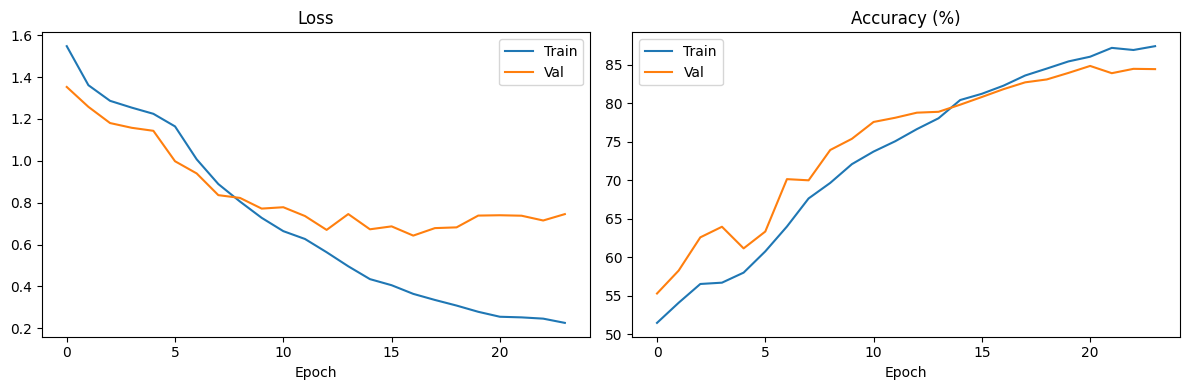

In [40]:
# ============================================================
# Cell 11: Train the Model
# ============================================================

# --- Checkpoint configuration ---
RESUME_FROM_CHECKPOINT = True  # Set True to resume from latest checkpoint
CHECKPOINT_PATH = os.path.join(DIR_NAME, "latest_checkpoint.pth")

# --- Build model ---
model = MultimodalSkinCancerModel(
    num_classes=len(CLASS_SCHEME),
    metadata_dim=train_dataset.get_metadata_dim(),
    freeze_backbone=cfg.model.freeze_backbone
).to(device)

# Weighted cross-entropy loss to handle class imbalance
criterion = nn.CrossEntropyLoss(weight=weights_tensor.to(device))

# --- Resume from checkpoint if requested ---
start_epoch = 1
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

if RESUME_FROM_CHECKPOINT and os.path.exists(CHECKPOINT_PATH):
    # Load checkpoint (weights_only=False needed for complex state dicts)
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    start_epoch = checkpoint["epoch"] + 1

    # Rebuild optimizer with the correct parameter group structure for the resumed epoch
    if start_epoch > cfg.train.unfreeze_epoch:
        # Past warmup phase — backbone should be unfrozen with lower LR
        model.unfreeze_backbone()
        optimizer = torch.optim.AdamW([
            {"params": model.backbone.parameters(), "lr": cfg.train.lr * cfg.train.backbone_lr_factor},
            {"params": model.meta_branch.parameters()},
            {"params": model.classifier.parameters()}
        ], lr=cfg.train.lr, weight_decay=cfg.train.weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.train.epochs - cfg.train.unfreeze_epoch)
    else:
        # Still in warmup phase — only trainable (unfrozen) params
        optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.train.lr, weight_decay=cfg.train.weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.train.epochs)

    # Restore optimizer, scheduler, and early stopping state
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    early_stopping = EarlyStopping(patience=cfg.train.patience)
    early_stopping.best_loss = checkpoint["best_loss"]
    early_stopping.counter = checkpoint["es_counter"]
    early_stopping.best_state = checkpoint["es_best_state"]
    history = checkpoint["history"]
    print(f"Resumed from epoch {checkpoint['epoch']} (best val_loss: {early_stopping.best_loss:.4f})")
elif RESUME_FROM_CHECKPOINT:
    print("No checkpoint found, starting fresh.")

if start_epoch == 1:
    # Fresh start — create optimizer, scheduler, early_stopping from scratch
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.train.lr, weight_decay=cfg.train.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.train.epochs)
    early_stopping = EarlyStopping(patience=cfg.train.patience)

print(f"Training on {device} | {cfg.train.epochs} epochs | LR={cfg.train.lr}")
print(f"Backbone frozen for first {cfg.train.unfreeze_epoch} epochs\n")

start_time = time.time()

# --- Training loop ---
for epoch in range(start_epoch, cfg.train.epochs + 1):
    # Unfreeze backbone after warmup phase
    if epoch == cfg.train.unfreeze_epoch + 1:
        model.unfreeze_backbone()
        # Reset optimizer with differential learning rates (backbone gets 10x lower LR)
        optimizer = torch.optim.AdamW([
            {"params": model.backbone.parameters(), "lr": cfg.train.lr * cfg.train.backbone_lr_factor},
            {"params": model.meta_branch.parameters()},
            {"params": model.classifier.parameters()}
        ], lr=cfg.train.lr, weight_decay=cfg.train.weight_decay)
        # New cosine annealing schedule for remaining epochs
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.train.epochs - cfg.train.unfreeze_epoch)
        print(f"\nBackbone unfrozen (epoch {epoch}) — LR: backbone={cfg.train.lr*cfg.train.backbone_lr_factor:.0e}, head={cfg.train.lr:.0e}")

    # Run one training and validation epoch
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    # Record metrics for plotting
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Print epoch summary with early stopping status
    lr_str = f"{optimizer.param_groups[0]['lr']:.1e}"
    print(f"Epoch {epoch:2d}/{cfg.train.epochs} | Train: {train_loss:.4f} ({train_acc:.1f}%) | Val: {val_loss:.4f} ({val_acc:.1f}%) | LR: {lr_str}", end="")

    # Check early stopping condition
    if early_stopping(val_loss, model):
        print(f" | :( Early stop (best val_loss: {early_stopping.best_loss:.4f})")
        break
    elif early_stopping.counter > 0:
        print(f" | patience {early_stopping.counter}/{cfg.train.patience}")
    else:
        print(f" | best! :D")

    # Save latest checkpoint (overwrite each epoch for crash recovery)
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "history": history,
        "best_loss": early_stopping.best_loss,
        "es_counter": early_stopping.counter,
        "es_best_state": early_stopping.best_state,
    }, CHECKPOINT_PATH)

elapsed = time.time() - start_time
print(f"\nTraining complete in {elapsed/60:.1f} min")

# Restore best model weights from early stopping
if early_stopping.best_state:
    model.load_state_dict(early_stopping.best_state)
    model.to(device)

# Save best model for evaluation
SAVE_PATH = os.path.join(DIR_NAME, "best_model.pth")
torch.save(model.state_dict(), SAVE_PATH)
print(f"Best model saved to {SAVE_PATH}")

# Save training history to JSON for later analysis
HISTORY_PATH = os.path.join(DIR_NAME, "training_history.json")
with open(HISTORY_PATH, "w") as f:
    json.dump(history, f, indent=2)
print(f"Training history saved to {HISTORY_PATH}")

# --- Plot training curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"], label="Val")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()
ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"], label="Val")
ax2.set_title("Accuracy (%)"); ax2.set_xlabel("Epoch"); ax2.legend()
plt.tight_layout()
plt.show()

COMPREHENSIVE EVALUATION

──────────────────────────────────────────────────
Internal Test (5302 samples)
──────────────────────────────────────────────────


   Loss: 0.6312 | Accuracy: 81.3%
   Balanced Accuracy: 0.7932
   Weighted F1:       0.8177
              precision    recall  f1-score   support

       akiec       0.60      0.56      0.58       179
         bcc       0.80      0.85      0.83       576
         bkl       0.62      0.83      0.71       558
          df       0.63      0.92      0.75        53
         mel       0.69      0.71      0.70       846
          nv       0.94      0.85      0.89      2937
         scc       0.50      0.67      0.57        94
        vasc       0.81      0.95      0.88        59

    accuracy                           0.81      5302
   macro avg       0.70      0.79      0.74      5302
weighted avg       0.83      0.81      0.82      5302



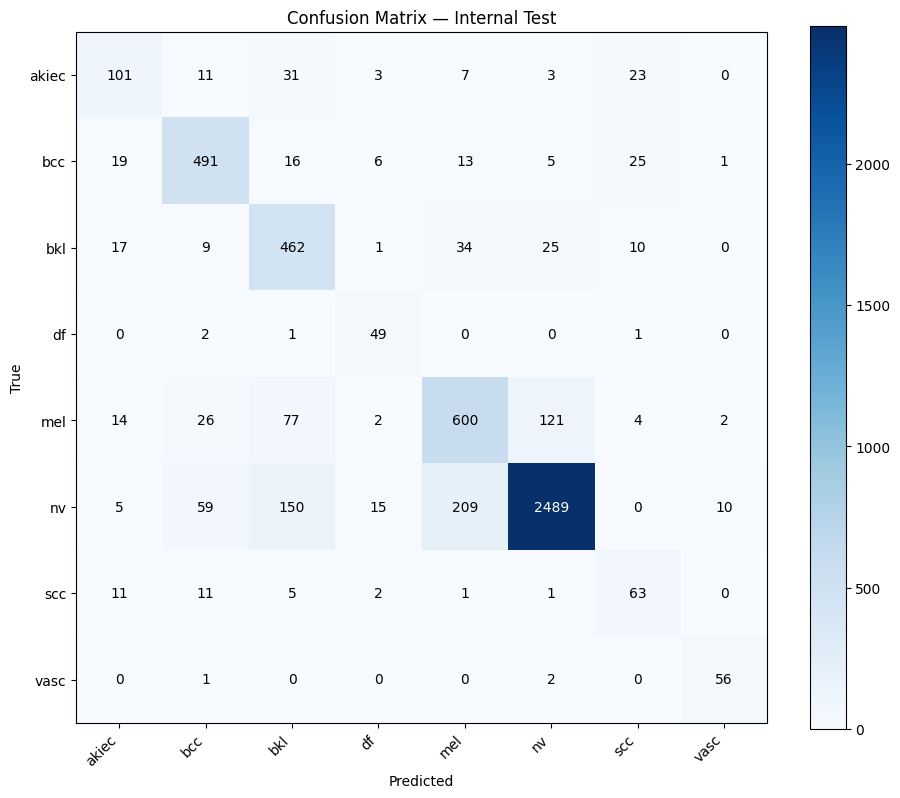

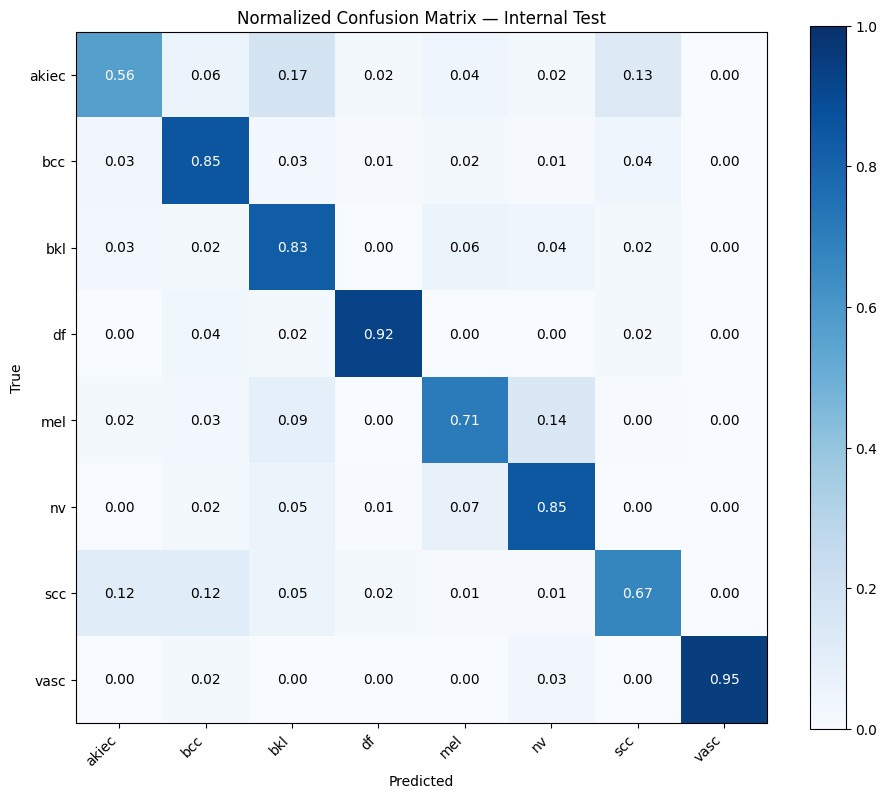


──────────────────────────────────────────────────
PH2 (Cross-dataset) (200 samples)
──────────────────────────────────────────────────


   Loss: 0.4694 | Accuracy: 86.0%
   Balanced Accuracy: 0.8187
   Weighted F1:       0.8882
              precision    recall  f1-score   support

         mel       0.73      0.75      0.74        40
          nv       0.97      0.89      0.93       160

   micro avg       0.91      0.86      0.89       200
   macro avg       0.85      0.82      0.83       200
weighted avg       0.92      0.86      0.89       200



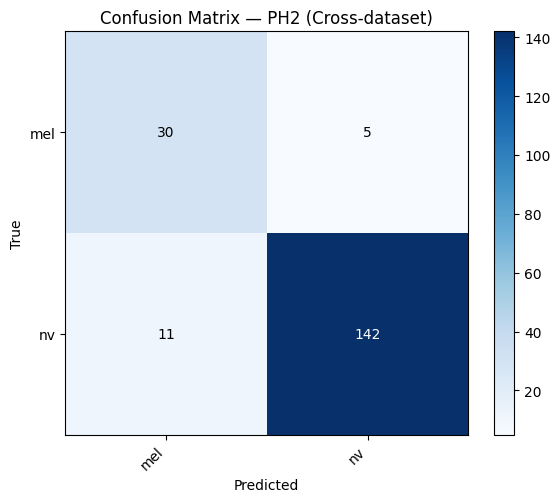

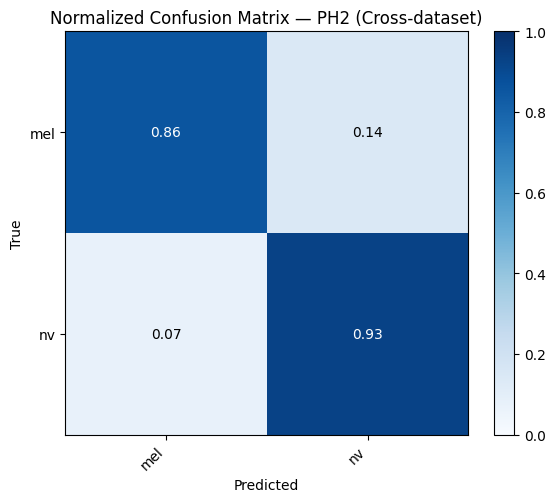


──────────────────────────────────────────────────
PAD-UFES-20 (Cross-domain) (2298 samples)
──────────────────────────────────────────────────


  Evaluating:  61%|██████    | 44/72 [01:16<00:52,  1.87s/it]

In [ ]:
# ============================================================
# Cell 12: Comprehensive Evaluation
# ============================================================
print("=" * 60)
print("COMPREHENSIVE EVALUATION")
print("=" * 60)

# Load best model from checkpoint for evaluation
try:
    checkpoint = torch.load(os.path.join(DIR_NAME, "best_model.pth"), map_location=device, weights_only=False)
    model.load_state_dict(checkpoint)
except Exception:
    checkpoint = torch.load(os.path.join(DIR_NAME, "latest_checkpoint.pth"), map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])

# Define all test sets: internal test + external cross-dataset evaluations
results = {}
test_sets = [
    ("Internal Test", test_loader, test_dataset),
    ("PH2 (Cross-dataset)", external_ph2_loader, external_ph2_dataset),
    ("PAD-UFES-20 (Cross-domain)", external_pad_loader, external_pad_dataset)
]

# Get class names from the training set's label encoder for reporting
all_class_names = list(train_dataset.label_encoder.classes_)

# Evaluate on each test set
for name, loader, dataset in test_sets:
    if loader is None:
        print(f"\n\u26a0\ufe0f {name}: skipped (no data)")
        continue
    print(f"\n{'\u2500' * 50}")
    print(f"{name} ({len(dataset)} samples)")
    print('\u2500' * 50)

    # Run evaluation and compute comprehensive metrics
    loss, acc, preds, labels = evaluate(model, loader, criterion, device)
    print(f"   Loss: {loss:.4f} | Accuracy: {acc:.1f}%")
    bal_acc, f1_w = compute_metrics(labels, preds, all_class_names)
    results[name] = {"accuracy": acc, "balanced_accuracy": bal_acc, "f1": f1_w, "loss": loss}

    # --- Raw confusion matrix ---
    # Only show classes that are present in the true labels
    present_indices = sorted(set(labels))
    present_names = [all_class_names[i] for i in present_indices]
    cm = confusion_matrix(labels, preds, labels=present_indices)
    # Normalize confusion matrix by row (true class) for per-class recall visualization
    cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims = True)

    # Plot raw confusion matrix
    fig, ax = plt.subplots(figsize=(max(6, len(present_names) * 1.2), max(5, len(present_names))))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax.set_title(f"Confusion Matrix \u2014 {name}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks(range(len(present_names))); ax.set_xticklabels(present_names, rotation=45, ha="right")
    ax.set_yticks(range(len(present_names))); ax.set_yticklabels(present_names)
    # Annotate each cell with its count
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

    # Plot normalized confusion matrix (shows per-class recall proportions)
    fig, ax = plt.subplots(figsize=(max(6, len(present_names) * 1.2), max(5, len(present_names))))
    im = ax.imshow(cm_normalized, interpolation="nearest", cmap=plt.cm.Blues, vmin=0, vmax=1)
    ax.set_title(f"Normalized Confusion Matrix \u2014 {name}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks(range(len(present_names))); ax.set_xticklabels(present_names, rotation=45, ha="right")
    ax.set_yticks(range(len(present_names))); ax.set_yticklabels(present_names)
    # Annotate each cell with its proportion
    for i in range(cm_normalized.shape[0]):
        for j in range(cm_normalized.shape[1]):
            ax.text(j, i, f"{cm_normalized[i,j]:.2f}", ha="center", va="center",
                    color="white" if cm_normalized[i, j] > 0.5 else "black")
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

# --- Final summary table ---
print(f"\n{'=' * 60}")
print(f"{'Test Set':<30} {'Acc':>6} {'Bal.Acc':>8} {'F1':>6} {'Loss':>7}")
print(f"{'-' * 60}")
for name, r in results.items():
    print(f"{name:<30} {r['accuracy']:>5.1f}% {r['balanced_accuracy']:>7.4f} {r['f1']:>5.3f} {r['loss']:>7.4f}")
print(f"{'=' * 60}")